Reference: https://www.kaggle.com/ryanholbrook/principal-component-analysis#kln-21

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_selection import mutual_info_regression

from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score

import seaborn as sns

In [2]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


In [3]:
theta_neg_w1 = ['c_w1_n1_theta', 'c_w1_n2_theta', 'c_w1_n3_theta']
theta_neg_w2 = ['c_w2_n1_theta', 'c_w2_n2_theta', 'c_w2_n3_theta']
theta_neg_w3 = ['c_w3_n1_theta', 'c_w3_n2_theta', 'c_w3_n3_theta']

theta_pos_w1 = ['c_w1_p1_theta', 'c_w1_p2_theta', 'c_w1_p3_theta']
theta_pos_w2 = ['c_w2_p1_theta', 'c_w2_p2_theta', 'c_w2_p3_theta']
theta_pos_w3 = ['c_w3_p1_theta', 'c_w3_p2_theta', 'c_w3_p3_theta']

deltas = ['n5s_delta', 'n15s_delta', 'n30s_delta', 'n60s_delta']


x_cols = ['c_w1_n1_theta', 'c_w1_n2_theta', 'c_w1_n3_theta',
          'c_w2_p1_theta', 'c_w2_p2_theta', 'c_w2_p3_theta', 
          'c_w3_n1_theta', 'c_w3_n2_theta', 'c_w3_n3_theta',
          'n5s_delta', 'n15s_delta', 'n30s_delta', 'n60s_delta']
y_cols = ['p30s_bucket']  # ,  'p5s_bucket', 'p30s_bucket', 'p60s_bucket']
bin_counts = 5

model_file_list = ['ml_cp18/ml_cp18_AAPL20220104.csv', 'ml_cp18/ml_cp18_AAPL20220106.csv']
test_file = "ml_cp18/ml_cp18_AAPL20220105-test.csv"


# Load Training Data

In [4]:
data_tmp = pd.read_csv("../"+model_file_list[0], low_memory=False)
data_tmp.shape

(18592, 267)

In [5]:
data = pd.read_csv("../"+model_file_list[1], low_memory=False)
data = data.append(data_tmp, ignore_index=True)
data.shape

(31825, 267)

In [6]:
data = data.dropna()
data.shape

(24321, 267)

In [7]:
x_train = data[ x_cols ]
y_train = data[ y_cols ].astype('int')

# Create XGB Model

In [8]:
params = {
        'copy_X': True,
        'fit_intercept': False,
        'normalize': True,
        '_kfold': 5,
        # 'objective': 'validation:accuracy',
        'objective': 'multi:softprob',
        'enable_categorical': False,
        '_tuning_objective_metric': 'validation:f1',
        'eval_metric': 'auc',
        # 'tree_method': 'gpu_hist',
        # 'eval_metric': 'accuracy,f1',
        # 'eval_metric':'merror',
        # 'eval_metric': 'accuracy,f1X',
        # Muthu params
        'subsample': 0.75,  # Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting.
        'gamma': 0.001, # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, the more conservative the algorithm will be
        'alpha': 0.0, # L1 regularization is Lasso Regression wich adds “squared magnitude” of coefficient as penalty term to the loss functi
        'lambda': 1.0, # L2 regularization is Ridge Regression which adds “absolute value of magnitude” of coefficient as penalty term to the loss function.
        'eta': 0.03, # Step size shrinkage used in update to prevents overfitting
        'min_child_weight': 0.05, # Minimum sum of instance weight (hessian) needed in a child the building process will give up further partitioning.
        'num_class': bin_counts,
        # not too sure.
        'max_depth': 10,  # Maximum tree depth for base learners.
        'early_stopping_rounds': 50,  # don't over fit
        'num_round': 100,  # num_boost_round == num_boost_round
        'use_label_encoder': False # UserWarning: The use of label encoder in XGBClassifier is deprecated...
    }
xgb = XGBClassifier(**params)

In [9]:
xgb.fit(x_train, y_train)

[19:03:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:576: 
Parameters: { "_kfold", "_tuning_objective_metric", "copy_X", "early_stopping_rounds", "fit_intercept", "normalize", "num_round" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




XGBClassifier(_kfold=5, _tuning_objective_metric='validation:f1', alpha=0.0,
              base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, copy_X=True,
              early_stopping_rounds=50, enable_categorical=False, eta=0.03,
              eval_metric='auc', fit_intercept=False, gamma=0.001, gpu_id=-1,
              importance_type=None, interaction_constraints='', lambda=1.0,
              learning_rate=0.0299999993, max_delta_step=0, max_depth=10,
              min_child_weight=0.05, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=10, normalize=True, num_class=5,
              num_parallel_tree=1, ...)

# Load Test Data

In [10]:
test_data = pd.read_csv("../"+ test_file, low_memory=False)
test_data.shape

(8347, 267)

In [11]:
all_cols = x_cols + y_cols
test_df = test_data [ all_cols ]
test_df = test_df.dropna()

x_test = test_df[ x_cols ]
y_test = test_df[ y_cols ].astype('int')

x_test.shape

(7749, 13)

# Base Prediction

In [12]:
y_pred = xgb.predict(x_test)

In [13]:
print('accuracy', accuracy_score( y_test[y_cols ], y_pred))

accuracy 0.2255774938701768


In [14]:
precision, recall, f1, y_true = precision_recall_fscore_support( y_test [y_cols ], y_pred, average=None)
y_true = y_true.astype('int')
accuracy = accuracy_score(y_test[ y_cols ], y_pred)
print (f"accuracy: {accuracy:.3f}")

accuracy: 0.226


In [15]:
pd.options.display.float_format = '{:,.3f}'.format
results_df =  pd.DataFrame( data = np.array ([recall,  precision, f1, y_true ] ),
                           columns = [ 'cat0', 'cat1', 'cat2', 'cat3','cat4'],
                           index = ['recall','precision', 'f1', 'y_true'] )
results_df

,cat0,cat1,cat2,cat3,cat4
recall,0.579,0.245,0.005,0.144,0.120
precision,0.217,0.240,0.163,0.230,0.240
f1,0.315,0.242,0.009,0.177,0.160
y_true,"1,605.000","1,725.000","1,452.000","1,406.000","1,561.000"


<AxesSubplot:>

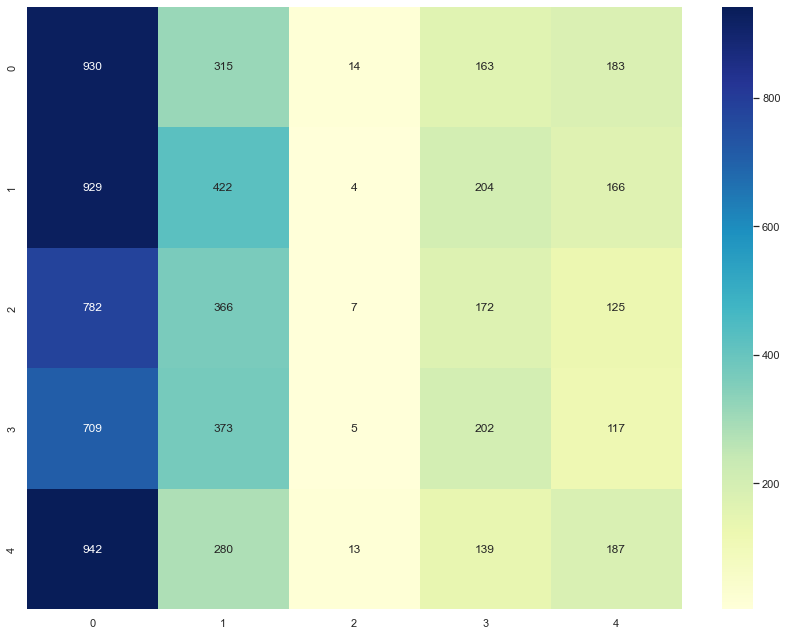

In [16]:
sns.set(rc = {'figure.figsize':(12,9)})
sns.heatmap(confusion_matrix(y_test[ y_cols ], y_pred), annot=True, cmap="YlGnBu",fmt='d')

# Standard Scaled X Prediction

In [17]:
scalar = StandardScaler()

scalar.fit(x_train)
x_scaled_train = scalar.transform(x_train)
x_scaled_test = scalar.transform(x_test)

In [18]:
xgb_scaled = XGBClassifier(**params)
xgb_scaled.fit(x_scaled_train, y_train)

[19:04:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:576: 
Parameters: { "_kfold", "_tuning_objective_metric", "copy_X", "early_stopping_rounds", "fit_intercept", "normalize", "num_round" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




XGBClassifier(_kfold=5, _tuning_objective_metric='validation:f1', alpha=0.0,
              base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, copy_X=True,
              early_stopping_rounds=50, enable_categorical=False, eta=0.03,
              eval_metric='auc', fit_intercept=False, gamma=0.001, gpu_id=-1,
              importance_type=None, interaction_constraints='', lambda=1.0,
              learning_rate=0.0299999993, max_delta_step=0, max_depth=10,
              min_child_weight=0.05, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=10, normalize=True, num_class=5,
              num_parallel_tree=1, ...)

In [19]:
y_scaled_pred = xgb_scaled.predict(x_scaled_test)

In [20]:
precision, recall, f1, y_true = precision_recall_fscore_support( y_test[y_cols ], y_scaled_pred, average=None)
y_true = y_true.astype('int')
accuracy = accuracy_score(y_test[ y_cols ], y_scaled_pred)
print (f"accuracy: {accuracy:.3f}")

accuracy: 0.227


In [21]:
pd.options.display.float_format = '{:,.3f}'.format
results_df =  pd.DataFrame( data = np.array ([recall,  precision, f1, y_true ] ),
                           columns = [ 'cat0', 'cat1', 'cat2', 'cat3','cat4'],
                           index = ['recall','precision', 'f1', 'y_true'] )
results_df

,cat0,cat1,cat2,cat3,cat4
recall,0.583,0.245,0.006,0.149,0.120
precision,0.218,0.246,0.195,0.228,0.239
f1,0.317,0.245,0.011,0.180,0.160
y_true,"1,605.000","1,725.000","1,452.000","1,406.000","1,561.000"


<AxesSubplot:>

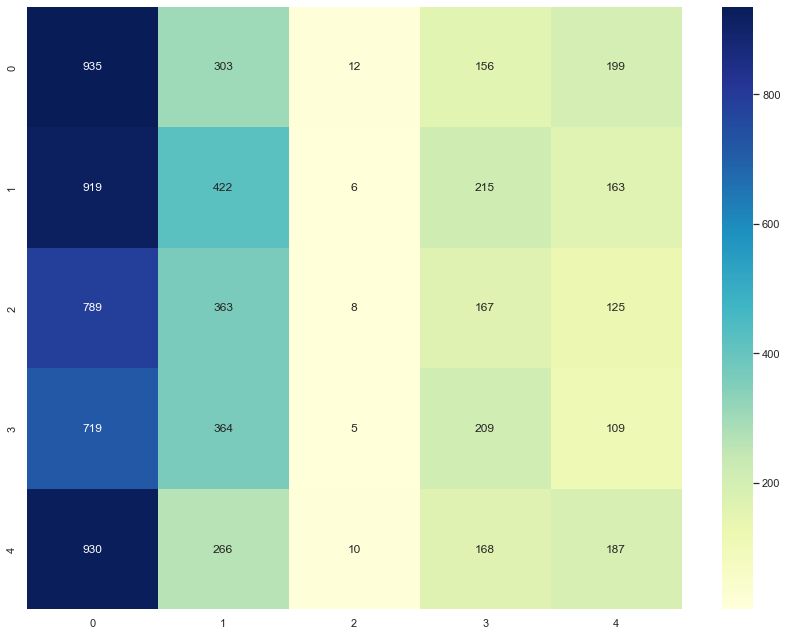

In [22]:
sns.set(rc = {'figure.figsize':(12,9)})
sns.heatmap(confusion_matrix(y_test[ y_cols ], y_scaled_pred), annot=True, cmap="YlGnBu",fmt='d')

# Adding PCA

Text(0, 0.5, 'Cumulative explained variance')

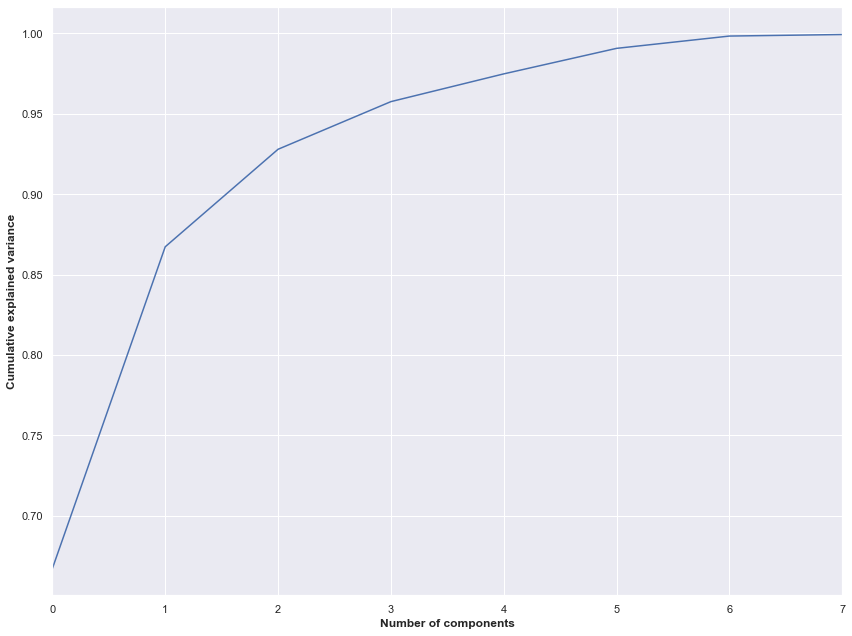

In [24]:
from sklearn.decomposition import PCA
pca = PCA().fit(x_scaled_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlim(0,7,1)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')

In [27]:
pca.explained_variance_ratio_

array([6.67136824e-01, 2.00149317e-01, 6.06665478e-02, 2.96403028e-02,
       1.72631146e-02, 1.58800553e-02, 7.65332283e-03, 9.54137121e-04,
       4.91674506e-04, 9.11384979e-05, 6.05437718e-05, 1.09896226e-05,
       2.03274047e-06])

array([<AxesSubplot:title={'center':'% Explained Variance'}, xlabel='Component'>,
       <AxesSubplot:title={'center':'% Cumulative Variance'}, xlabel='Component'>],
      dtype=object)

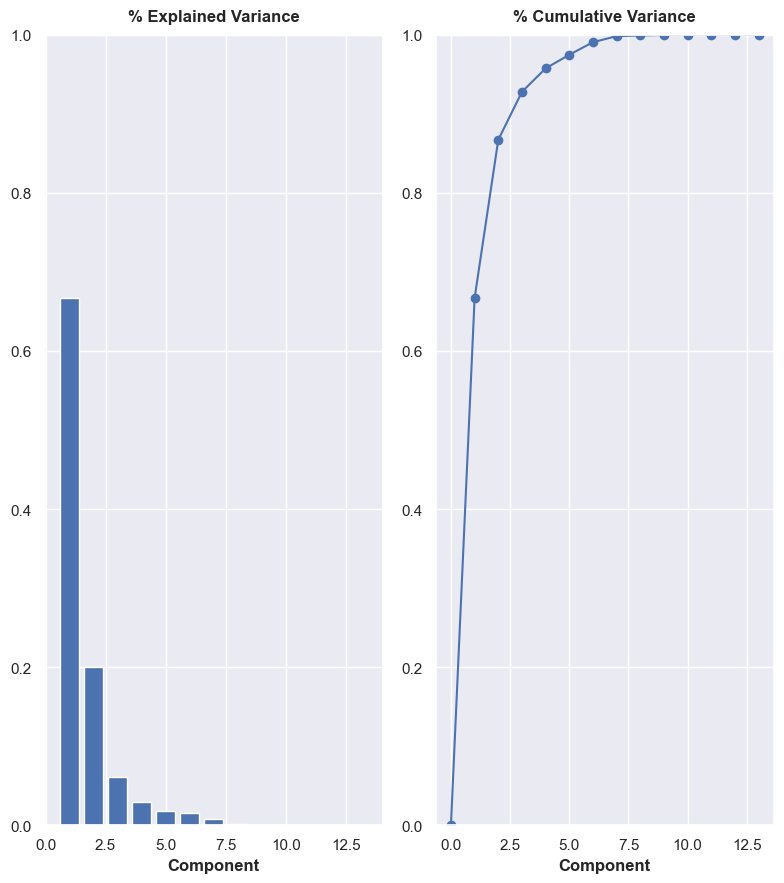

In [28]:
plot_variance(pca)

In [36]:
mi_scores = make_mi_scores(x_train, y_train[ y_cols ], discrete_features=False)
mi_scores

/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/sklearn/utils/validation.py:985: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


c_w3_n2_theta   0.511
c_w2_p3_theta   0.500
c_w3_n1_theta   0.494
c_w3_n3_theta   0.485
c_w2_p2_theta   0.484
c_w2_p1_theta   0.483
c_w1_n1_theta   0.473
c_w1_n2_theta   0.451
c_w1_n3_theta   0.422
n30s_delta      0.025
n60s_delta      0.019
n15s_delta      0.010
n5s_delta       0.005
Name: MI Scores, dtype: float64